In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet(
    "county_month_combined.parquet"
)

print(df.shape)
df.head()

(17407, 10)


,county,year_month,sales_dollars,sales_bottles,sales_liters,sales_gallons,num_stores,avg_alcohol_level_g210L,num_tests,county_population
0,ADAIR,2012-01,24967.11,2263,2165.94,572.06,8,0.124,24.0,7468.0
1,ADAIR,2012-02,28078.87,2559,2569.06,678.40,7,0.124,24.0,7468.0
2,ADAIR,2012-03,25380.59,2285,2197.89,580.46,7,0.124,24.0,7468.0
3,ADAIR,2012-04,36608.04,3097,2915.09,769.73,8,0.124,24.0,7468.0
4,ADAIR,2012-05,35782.93,3086,3055.53,806.78,8,0.124,24.0,7468.0


In [ ]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
county_population,1980,11.374734
avg_alcohol_level_g210L,8,0.045959
num_tests,8,0.045959
county,0,0.000000
year_month,0,0.000000
sales_dollars,0,0.000000
sales_gallons,0,0.000000
sales_liters,0,0.000000
sales_bottles,0,0.000000
num_stores,0,0.000000


In [ ]:
employment = pd.read_parquet(
    "employment_status_for_iowa_civilian_population_16_years_old_and_over_acs_1_year_estimate_1188_rows.parquet"
)

employment.shape

(34560, 27)

In [ ]:
emp_county = employment[
    employment["geography_type"] == "County"
].copy()

print("County employment rows:", len(emp_county))
print(
    "Unique counties:",
    emp_county["county_fips_code"].nunique()
)

print("\nCounties represented by year:")

print(
    emp_county
    .groupby("data_collection_period")
    ["county_fips_code"]
    .nunique()
)

County employment rows: 18600
Unique counties: 10

Counties represented by year:
data_collection_period
2010    10
2011    10
2012    10
2013    10
2014    10
2015    10
2016    10
2017    10
2018    10
2019    10
2021    10
2022    10
2023    10
2024    10
Name: county_fips_code, dtype: int64


In [ ]:
#Only 10 counties are represented in the employment dataset
employment_cols = [
    col for col in df.columns
    if col.startswith("S2301_")
]

print("Employment columns:", len(employment_cols))

Employment columns: 0


In [ ]:
df_main = df.drop(
    columns=employment_cols
).copy()

df_main.shape

(17407, 10)

We initially considered ACS 1-year employment estimates as predictors. Exploratory analysis showed that the dataset covered only 10 Iowa counties, which would exclude most counties from models requiring these variables. Because this missingness was systematically related to geographic coverage rather than random missing observations, we excluded these variables from our primary statewide models rather than dropping counties or imputing unsupported values.

In [ ]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17407 entries, 0 to 17406
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   17407 non-null  object 
 1   year_month               17407 non-null  object 
 2   sales_dollars            17407 non-null  float64
 3   sales_bottles            17407 non-null  int64  
 4   sales_liters             17407 non-null  float64
 5   sales_gallons            17407 non-null  float64
 6   num_stores               17407 non-null  int64  
 7   avg_alcohol_level_g210L  17399 non-null  float64
 8   num_tests                17399 non-null  float64
 9   county_population        15427 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 1.3+ MB


In [ ]:
df_main.columns.tolist()

['county',
 'year_month',
 'sales_dollars',
 'sales_bottles',
 'sales_liters',
 'sales_gallons',
 'num_stores',
 'avg_alcohol_level_g210L',
 'num_tests',
 'county_population']

In [ ]:
#Separate year and month
df_main["year_month"] = pd.to_datetime(
    df_main["year_month"]
)

df_main["year"] = df_main["year_month"].dt.year
df_main["month"] = df_main["year_month"].dt.month

In [ ]:
#all counties represented
df_main.groupby("year").agg(
    rows=("county", "size"),
    counties=("county", "nunique")
)

,rows,counties
year,,
2012,1187,99
2013,1186,99
2014,1183,99
2015,1186,99
2016,1187,99
2017,1188,99
2018,1188,99
2019,1184,99
2020,1186,99


In [ ]:
#Check for duplicates
duplicates = (
    df_main.groupby(["county", "year_month"])
      .size()
      .reset_index(name="count")
)

duplicates[
    duplicates["count"] > 1
]

,county,year_month,count


In [ ]:
#Population not represented in 2025-2026
population_coverage = (
    df_main.groupby("year")
      .agg(
          counties=("county", "nunique"),
          counties_with_population=(
              "county_population",
              lambda x: x.notna().sum()
          )
      )
)

population_coverage

,counties,counties_with_population
year,,
2012,99,1187
2013,99,1186
2014,99,1183
2015,99,1186
2016,99,1187
2017,99,1188
2018,99,1188
2019,99,1184
2020,99,1186


In [ ]:
#BAC represented in all rows
bac_coverage = (
    df_main.groupby("year")
      .agg(
          counties=("county", "nunique"),
          counties_with_population=(
              "avg_alcohol_level_g210L",
              lambda x: x.notna().sum()
          )
      )
)

bac_coverage

,counties,counties_with_population
year,,
2012,99,1187
2013,99,1186
2014,99,1183
2015,99,1186
2016,99,1187
2017,99,1188
2018,99,1188
2019,99,1184
2020,99,1186


In [ ]:
booze = df_main[
    [
        "county",
        "year_month",
        "year",
        "month",
        "sales_dollars",
        "sales_bottles",
        "sales_liters",
        "sales_gallons",
        "county_population"
    ]
].copy()

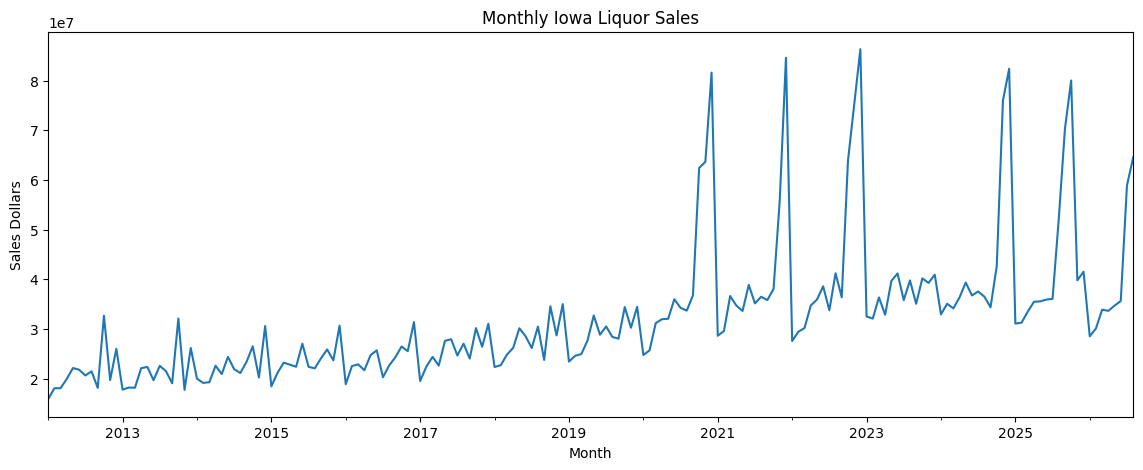

In [ ]:
state_monthly = (
    booze.groupby("year_month")["sales_dollars"]
         .sum()
)

state_monthly.plot(
    figsize=(14, 5),
    title="Monthly Iowa Liquor Sales"
)

plt.ylabel("Sales Dollars")
plt.xlabel("Month")
plt.show()

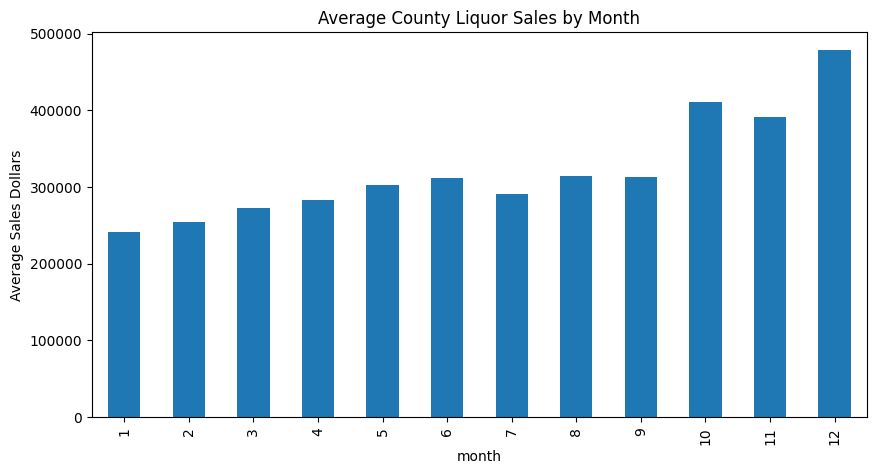

In [ ]:
monthly_pattern = (
    booze[
        booze["year"] < 2026
    ]
    .groupby("month")["sales_dollars"]
    .mean()
)

monthly_pattern.plot(
    kind="bar",
    figsize=(10, 5),
    title="Average County Liquor Sales by Month"
)

plt.ylabel("Average Sales Dollars")
plt.show()

In [ ]:
#Average monthly sales by county
county_avg = (
    booze.groupby("county")["sales_dollars"]
         .mean()
         .sort_values(ascending=False)
)

county_avg.head(15)

,sales_dollars
county,
POLK,7.389746e+06
LINN,2.782284e+06
SCOTT,2.212532e+06
JOHNSON,1.887965e+06
BLACK HAWK,1.729035e+06
POTTAWATTAMIE,1.170590e+06
WOODBURY,1.110240e+06
STORY,9.459282e+05
DUBUQUE,9.421202e+05


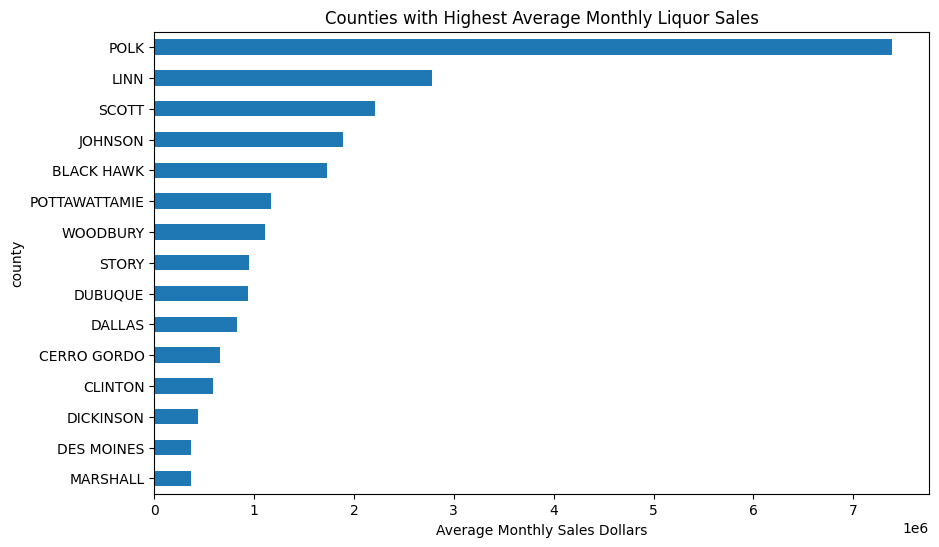

In [ ]:
county_avg.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Counties with Highest Average Monthly Liquor Sales"
)

plt.xlabel("Average Monthly Sales Dollars")
plt.show()

In [ ]:
booze["sales_dollars"].describe()

,sales_dollars
count,1.740700e+04
mean,3.259836e+05
std,9.337577e+05
min,7.941600e+02
25%,4.502111e+04
50%,9.428905e+04
75%,2.053419e+05
max,2.042934e+07


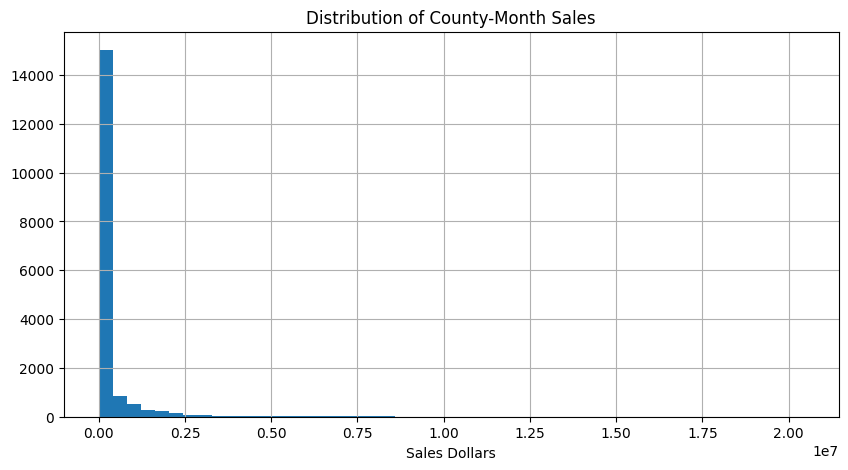

In [ ]:
booze["sales_dollars"].hist(
    bins=50,
    figsize=(10, 5)
)

plt.title("Distribution of County-Month Sales")
plt.xlabel("Sales Dollars")
plt.show()

In [ ]:
#New variables with county sales from: 1. Month before 2. Same month previous year 3. previous 3 month average 4. previous 12 month average

booze = booze.sort_values(
    ["county", "year_month"]
).reset_index(drop=True)

county_group = booze.groupby("county")

booze["sales_lag_1"] = (
    county_group["sales_dollars"]
    .shift(1)
)

booze["sales_lag_12"] = (
    county_group["sales_dollars"]
    .shift(12)
)

booze["sales_previous_3mo_avg"] = (
    county_group["sales_dollars"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

booze["sales_previous_12mo_avg"] = (
    county_group["sales_dollars"]
    .transform(
        lambda x: x.shift(1).rolling(12).mean()
    )
)

In [ ]:
booze[
    [
        "sales_dollars",
        "sales_lag_1",
        "sales_lag_12",
        "sales_previous_3mo_avg",
        "sales_previous_12mo_avg"
    ]
].corr()

,sales_dollars,sales_lag_1,sales_lag_12,sales_previous_3mo_avg,sales_previous_12mo_avg
sales_dollars,1.000000,0.936233,0.944179,0.930185,0.945494
sales_lag_1,0.936233,1.000000,0.919001,0.971707,0.951014
sales_lag_12,0.944179,0.919001,1.000000,0.932853,0.954814
sales_previous_3mo_avg,0.930185,0.971707,0.932853,1.000000,0.976593
sales_previous_12mo_avg,0.945494,0.951014,0.954814,0.976593,1.000000


In [ ]:
#Create baseline prediction
booze_model = booze.dropna(
    subset=["sales_lag_12"]
).copy()

booze_model["baseline_prediction"] = (
    booze_model["sales_lag_12"]
)

In [ ]:
#Error metrics
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )

def mae(y_true, y_pred):
    return np.mean(
        np.abs(y_true - y_pred)
    )

In [ ]:
#3-fold split
train = booze_model[
    booze_model["year"] <= 2023
].copy()

validation = booze_model[
    booze_model["year"] == 2024
].copy()

test = booze_model[
    booze_model["year"] == 2025
].copy()

In [ ]:
print(
    "Validation baseline RMSE:",
    rmse(
        validation["sales_dollars"],
        validation["baseline_prediction"]
    )
)

print(
    "Validation baseline MAE:",
    mae(
        validation["sales_dollars"],
        validation["baseline_prediction"]
    )
)

Validation baseline RMSE: 432509.76431835536
Validation baseline MAE: 98071.05350168348


In [ ]:
#Booze Model

from sklearn.linear_model import LinearRegression

X_train = train[
    ["sales_lag_12"]
]

y_train = train["sales_dollars"]

X_val = validation[
    ["sales_lag_12"]
]

y_val = validation["sales_dollars"]

model1 = LinearRegression()

model1.fit(
    X_train,
    y_train
)

pred1 = model1.predict(X_val)

print("RMSE:", rmse(y_val, pred1))
print("MAE:", mae(y_val, pred1))

print("Intercept:", model1.intercept_)
print("Coefficient:", model1.coef_)

RMSE: 431468.07849115494
MAE: 98823.36331521694
Intercept: 15397.123526570038
Coefficient: [0.99742224]


In [ ]:
#Better results may be caused due to multicollinearity

features2 = [
    "sales_lag_1",
    "sales_lag_12"
]

X_train = train[features2]
X_val = validation[features2]

model2 = LinearRegression()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_val)

print("RMSE:", rmse(y_val, pred2))
print("MAE:", mae(y_val, pred2))

RMSE: 346783.8483197493
MAE: 85920.14415395424


In [ ]:
#Better results may be caused due to multicollinearity

features3 = [
    "sales_lag_1",
    "sales_lag_12",
    "sales_previous_3mo_avg",
    "sales_previous_12mo_avg"
]

model3 = LinearRegression()

model3.fit(
    train[features3],
    y_train
)

pred3 = model3.predict(
    validation[features3]
)

print("RMSE:", rmse(y_val, pred3))
print("MAE:", mae(y_val, pred3))

RMSE: 362666.81240227475
MAE: 87684.2101985545


In [ ]:
#New model for seasonality

month_dummies = pd.get_dummies(
    booze_model["month"],
    prefix="month",
    drop_first=True,
    dtype=int
)

booze_model = pd.concat(
    [booze_model, month_dummies],
    axis=1
)

In [ ]:
train = booze_model[
    booze_model["year"] <= 2023
].copy()

validation = booze_model[
    booze_model["year"] == 2024
].copy()

test = booze_model[
    booze_model["year"] == 2025
].copy()

In [ ]:
month_features = [
    f"month_{i}"
    for i in range(2, 13)
]

features4 = [
    "sales_lag_1",
    "sales_lag_12",
] + month_features

model4 = LinearRegression()

model4.fit(
    train[features4],
    train["sales_dollars"]
)

pred4 = model4.predict(
    validation[features4]
)

print(
    "RMSE:",
    rmse(
        validation["sales_dollars"],
        pred4
    )
)

print(
    "MAE:",
    mae(
        validation["sales_dollars"],
        pred4
    )
)

RMSE: 342160.4615309143
MAE: 89310.45736086465


In [ ]:
results_booze = pd.DataFrame({
    "Model": [
        "Previous-year baseline",
        "Lag 12 regression",
        "Lag 1 + Lag 12",
        "Rolling history",
        "Lag 1 + Lag 12 + Month"
    ],

    "RMSE": [
        rmse(
            validation["sales_dollars"],
            validation["sales_lag_12"]
        ),
        rmse(validation["sales_dollars"], pred1),
        rmse(validation["sales_dollars"], pred2),
        rmse(validation["sales_dollars"], pred3),
        rmse(validation["sales_dollars"], pred4)
    ],

    "MAE": [
        mae(
            validation["sales_dollars"],
            validation["sales_lag_12"]
        ),
        mae(validation["sales_dollars"], pred1),
        mae(validation["sales_dollars"], pred2),
        mae(validation["sales_dollars"], pred3),
        mae(validation["sales_dollars"], pred4)
    ]
})

results_booze.sort_values("RMSE")

,Model,RMSE,MAE
4,Lag 1 + Lag 12 + Month,342160.461531,89310.457361
2,Lag 1 + Lag 12,346783.848320,85920.144154
3,Rolling history,362666.812402,87684.210199
1,Lag 12 regression,431468.078491,98823.363315
0,Previous-year baseline,432509.764318,98071.053502


In [ ]:
final_features = [
    "sales_lag_1",
    "sales_lag_12"
] + month_features

print("Final features:")
print(final_features)
# Chosen based on RMSE

Final features:
['sales_lag_1', 'sales_lag_12', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']


In [ ]:
#Retraining through 2024:
train_final = booze_model[
    booze_model["year"] <= 2024
].copy()

test_final = booze_model[
    booze_model["year"] == 2025
].copy()

final_model = LinearRegression()

final_model.fit(
    train_final[final_features],
    train_final["sales_dollars"]
)

final_coefficients = pd.DataFrame({
    "feature": final_features,
    "coefficient": final_model.coef_
})

print("Intercept:")
print(final_model.intercept_)

final_coefficients

#Testing on 2025
test_final = test_final.copy()

test_final["predicted_sales"] = (
    final_model.predict(
        test_final[final_features]
    )
)

test_final["residual"] = (
    test_final["sales_dollars"]
    - test_final["predicted_sales"]
)

test_final["absolute_error"] = (
    test_final["residual"].abs()
)

#Performance:
final_test_rmse = rmse(
    test_final["sales_dollars"],
    test_final["predicted_sales"]
)

final_test_mae = mae(
    test_final["sales_dollars"],
    test_final["predicted_sales"]
)

print(
    "Final 2025 Test RMSE:",
    round(final_test_rmse, 2)
)

print(
    "Final 2025 Test MAE:",
    round(final_test_mae, 2)
)

#Compared to baseline:
baseline_test_rmse = rmse(
    test_final["sales_dollars"],
    test_final["sales_lag_12"]
)

baseline_test_mae = mae(
    test_final["sales_dollars"],
    test_final["sales_lag_12"]
)

print(
    "2025 Baseline RMSE:",
    round(baseline_test_rmse, 2)
)

print(
    "2025 Final Model RMSE:",
    round(final_test_rmse, 2)
)

print()

print(
    "2025 Baseline MAE:",
    round(baseline_test_mae, 2)
)

print(
    "2025 Final Model MAE:",
    round(final_test_mae, 2)
)

#Improvement
rmse_improvement = (
    (baseline_test_rmse - final_test_rmse)
    / baseline_test_rmse
    * 100
)

mae_improvement = (
    (baseline_test_mae - final_test_mae)
    / baseline_test_mae
    * 100
)

print(
    "RMSE improvement over baseline:",
    round(rmse_improvement, 1),
    "%"
)

print(
    "MAE improvement over baseline:",
    round(mae_improvement, 1),
    "%"
)

Intercept:
-93641.78295655153
Final 2025 Test RMSE: 549394.79
Final 2025 Test MAE: 152993.45
2025 Baseline RMSE: 619570.7
2025 Final Model RMSE: 549394.79

2025 Baseline MAE: 162536.89
2025 Final Model MAE: 152993.45
RMSE improvement over baseline: 11.3 %
MAE improvement over baseline: 5.9 %


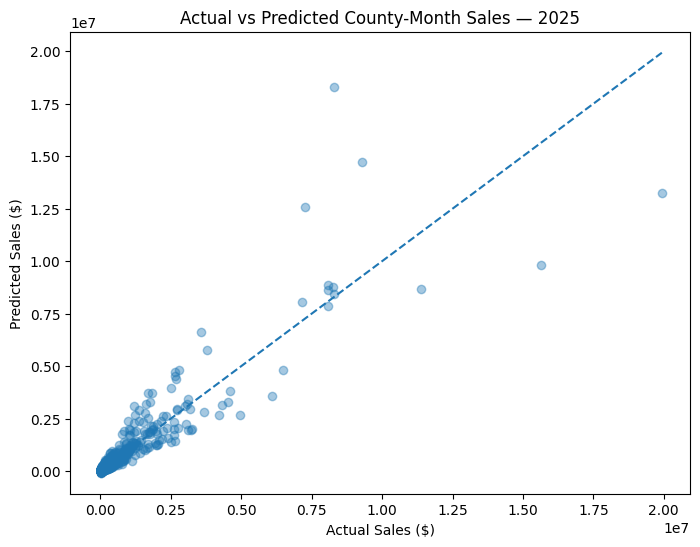

In [ ]:
#Actual versus predicted 2025
plt.figure(figsize=(8, 6))

plt.scatter(
    test_final["sales_dollars"],
    test_final["predicted_sales"],
    alpha=0.4
)

minimum = min(
    test_final["sales_dollars"].min(),
    test_final["predicted_sales"].min()
)

maximum = max(
    test_final["sales_dollars"].max(),
    test_final["predicted_sales"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Sales ($)")
plt.ylabel("Predicted Sales ($)")
plt.title("Actual vs Predicted County-Month Sales — 2025")

plt.show()

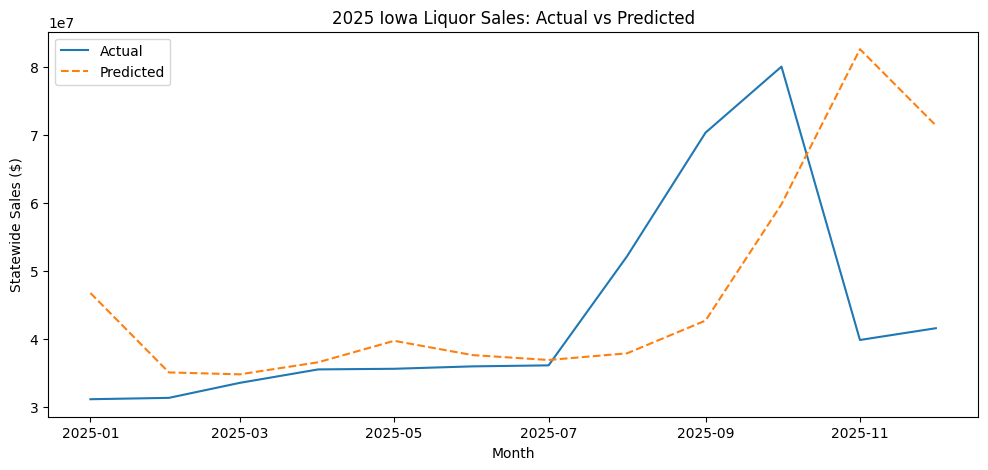

In [ ]:
#By state
state_test = (
    test_final
    .groupby("year_month")
    .agg(
        actual_sales=("sales_dollars", "sum"),
        predicted_sales=("predicted_sales", "sum")
    )
    .reset_index()
)

state_test.head()

plt.figure(figsize=(12, 5))

plt.plot(
    state_test["year_month"],
    state_test["actual_sales"],
    label="Actual"
)

plt.plot(
    state_test["year_month"],
    state_test["predicted_sales"],
    label="Predicted",
    linestyle="--"
)

plt.xlabel("Month")
plt.ylabel("Statewide Sales ($)")
plt.title("2025 Iowa Liquor Sales: Actual vs Predicted")

plt.legend()

plt.show()

In [ ]:
actual_2025 = (
    test_final["sales_dollars"].sum()
)

predicted_2025 = (
    test_final["predicted_sales"].sum()
)

total_error_pct = (
    (predicted_2025 - actual_2025)
    / actual_2025
    * 100
)

print(
    "Actual 2025 sales:",
    f"${actual_2025:,.0f}"
)

print(
    "Predicted 2025 sales:",
    f"${predicted_2025:,.0f}"
)

print(
    "Statewide prediction error:",
    f"{total_error_pct:.2f}%"
)

Actual 2025 sales: $522,799,273
Predicted 2025 sales: $561,421,792
Statewide prediction error: 7.39%


In [ ]:
test_final[
    [
        "county",
        "year_month",
        "sales_dollars",
        "predicted_sales",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
).head(20)

,county,year_month,sales_dollars,predicted_sales,absolute_error
13525,POLK,2025-11-01,8301332.00,1.831958e+07,1.001825e+07
13524,POLK,2025-10-01,19930763.88,1.322925e+07,6.701512e+06
13523,POLK,2025-09-01,15657748.26,9.828701e+06,5.829047e+06
13526,POLK,2025-12-01,9282797.00,1.471877e+07,5.435974e+06
13515,POLK,2025-01-01,7269994.56,1.257207e+07,5.302076e+06
10005,LINN,2025-11-01,3576437.00,6.625079e+06,3.048642e+06
13522,POLK,2025-08-01,11368302.78,8.652077e+06,2.716226e+06
10003,LINN,2025-09-01,6095065.00,3.556923e+06,2.538142e+06
14403,SCOTT,2025-09-01,4954519.38,2.655194e+06,2.299326e+06
14405,SCOTT,2025-11-01,2780253.00,4.837992e+06,2.057739e+06


In [ ]:
test_final[
    [
        "county",
        "year_month",
        "sales_dollars",
        "predicted_sales",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
).head(20)

,county,year_month,sales_dollars,predicted_sales,absolute_error
13525,POLK,2025-11-01,8301332.00,1.831958e+07,1.001825e+07
13524,POLK,2025-10-01,19930763.88,1.322925e+07,6.701512e+06
13523,POLK,2025-09-01,15657748.26,9.828701e+06,5.829047e+06
13526,POLK,2025-12-01,9282797.00,1.471877e+07,5.435974e+06
13515,POLK,2025-01-01,7269994.56,1.257207e+07,5.302076e+06
10005,LINN,2025-11-01,3576437.00,6.625079e+06,3.048642e+06
13522,POLK,2025-08-01,11368302.78,8.652077e+06,2.716226e+06
10003,LINN,2025-09-01,6095065.00,3.556923e+06,2.538142e+06
14403,SCOTT,2025-09-01,4954519.38,2.655194e+06,2.299326e+06
14405,SCOTT,2025-11-01,2780253.00,4.837992e+06,2.057739e+06


In [ ]:
print(
    "Latest month in dataset:",
    booze["year_month"].max()
)

Latest month in dataset: 2026-08-01 00:00:00


In [ ]:
forecast_history = (
    booze[
        booze["year"] <= 2025
    ][
        [
            "county",
            "year_month",
            "sales_dollars"
        ]
    ]
    .copy()
)

forecast_history = forecast_history.sort_values(
    ["county", "year_month"]
)

In [ ]:
forecast_rows = []
for month in range(1, 13):

    forecast_date = pd.Timestamp(
        year=2026,
        month=month,
        day=1
    )

    for county in forecast_history["county"].unique():

        county_history = (
            forecast_history[
                forecast_history["county"] == county
            ]
            .sort_values("year_month")
        )

        # Previous month
        previous_month_date = (
            forecast_date
            - pd.DateOffset(months=1)
        )

        lag1_row = county_history[
            county_history["year_month"]
            == previous_month_date
        ]

        # Same month previous year
        previous_year_date = (
            forecast_date
            - pd.DateOffset(months=12)
        )

        lag12_row = county_history[
            county_history["year_month"]
            == previous_year_date
        ]

        if (
            len(lag1_row) == 0
            or len(lag12_row) == 0
        ):
            continue

        sales_lag_1 = (
            lag1_row["sales_dollars"].iloc[0]
        )

        sales_lag_12 = (
            lag12_row["sales_dollars"].iloc[0]
        )

        row = {
            "sales_lag_1": sales_lag_1,
            "sales_lag_12": sales_lag_12
        }

        # January is reference category
        for m in range(2, 13):
            row[f"month_{m}"] = (
                1 if month == m else 0
            )

        X_forecast = pd.DataFrame(
            [row]
        )[final_features]

        prediction = (
            final_model.predict(
                X_forecast
            )[0]
        )

        # Prevent impossible negative sales
        prediction = max(
            prediction,
            0
        )

        forecast_rows.append({
            "county": county,
            "year_month": forecast_date,
            "predicted_sales": prediction
        })

        # Add prediction back into history
        # so February can use January forecast,
        # March can use February forecast, etc.
        new_history_row = pd.DataFrame({
            "county": [county],
            "year_month": [forecast_date],
            "sales_dollars": [prediction]
        })

        forecast_history = pd.concat(
            [
                forecast_history,
                new_history_row
            ],
            ignore_index=True
        )

In [ ]:
forecast_2026 = pd.DataFrame(
    forecast_rows
)

forecast_2026.head()

,county,year_month,predicted_sales
0,ADAIR,2026-01-01,0.0
1,ADAMS,2026-01-01,0.0
2,ALLAMAKEE,2026-01-01,0.0
3,APPANOOSE,2026-01-01,0.0
4,AUDUBON,2026-01-01,0.0


In [ ]:
projected_2026_sales = (
    forecast_2026["predicted_sales"].sum()
)

print(
    "Projected 2026 Iowa liquor sales:",
    f"${projected_2026_sales:,.0f}"
)
sales_2025 = (
    booze[
        booze["year"] == 2025
    ]["sales_dollars"].sum()
)

projected_growth = (
    (projected_2026_sales - sales_2025)
    / sales_2025
    * 100
)

print(
    "2025 sales:",
    f"${sales_2025:,.0f}"
)

print(
    "Projected 2026 sales:",
    f"${projected_2026_sales:,.0f}"
)

print(
    "Projected growth:",
    f"{projected_growth:.1f}%"
)

Projected 2026 Iowa liquor sales: $548,865,563
2025 sales: $522,799,273
Projected 2026 sales: $548,865,563
Projected growth: 5.0%


In [ ]:
historical_state = (
    booze[
        booze["year"] <= 2025
    ]
    .groupby("year_month")["sales_dollars"]
    .sum()
    .reset_index()
)

In [ ]:
forecast_state = (
    forecast_2026
    .groupby("year_month")["predicted_sales"]
    .sum()
    .reset_index()
)

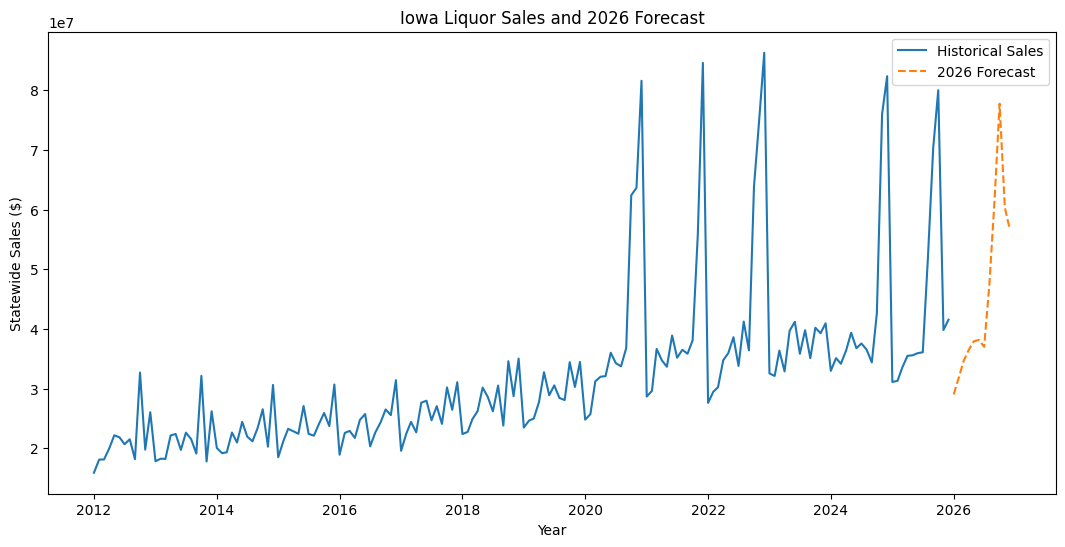

In [ ]:
plt.figure(figsize=(13, 6))

plt.plot(
    historical_state["year_month"],
    historical_state["sales_dollars"],
    label="Historical Sales"
)

plt.plot(
    forecast_state["year_month"],
    forecast_state["predicted_sales"],
    label="2026 Forecast",
    linestyle="--"
)

plt.xlabel("Year")
plt.ylabel("Statewide Sales ($)")
plt.title("Iowa Liquor Sales and 2026 Forecast")

plt.legend()

plt.show()

In [ ]:
forecast_monthly = (
    forecast_2026
    .groupby(
        forecast_2026["year_month"].dt.month
    )["predicted_sales"]
    .sum()
    .reset_index()
)

forecast_monthly.columns = [
    "month",
    "predicted_sales"
]

forecast_monthly[
    "month_name"
] = pd.to_datetime(
    forecast_monthly["month"],
    format="%m"
).dt.month_name()

forecast_monthly.sort_values(
    "predicted_sales",
    ascending=False
)

,month,predicted_sales,month_name
9,10,7.774816e+07,October
8,9,6.158769e+07,September
10,11,6.037342e+07,November
11,12,5.660698e+07,December
7,8,4.739211e+07,August
5,6,3.815170e+07,June
4,5,3.793720e+07,May
6,7,3.699394e+07,July
3,4,3.651806e+07,April
2,3,3.464129e+07,March


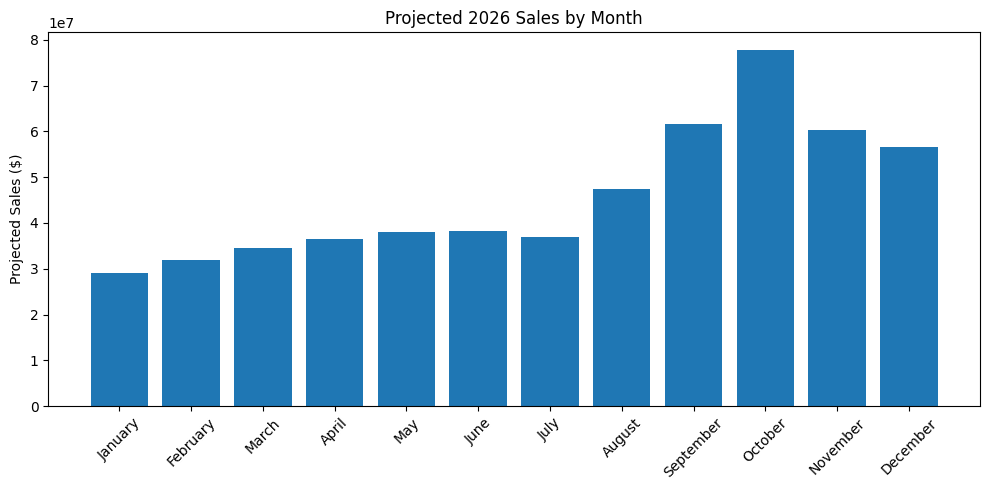

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    forecast_monthly["month_name"],
    forecast_monthly["predicted_sales"]
)

plt.xticks(rotation=45)

plt.ylabel("Projected Sales ($)")
plt.title("Projected 2026 Sales by Month")

plt.tight_layout()

plt.show()

In [ ]:
county_forecast = (
    forecast_2026
    .groupby("county")["predicted_sales"]
    .sum()
    .sort_values(ascending=False)
)

county_forecast.head(15)

,predicted_sales
county,
POLK,1.249637e+08
LINN,4.679375e+07
SCOTT,3.489079e+07
JOHNSON,3.157872e+07
BLACK HAWK,2.534711e+07
POTTAWATTAMIE,2.043631e+07
WOODBURY,1.864135e+07
DALLAS,1.856818e+07
DUBUQUE,1.572436e+07


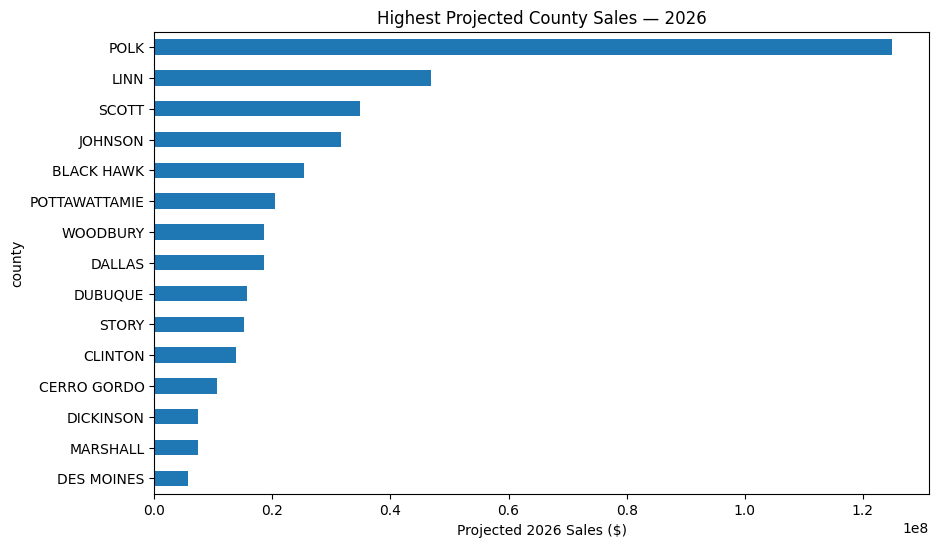

In [ ]:
county_forecast.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Projected 2026 Sales ($)")
plt.title("Highest Projected County Sales — 2026")

plt.show()

In [ ]:
county_year_sales = (
    booze[
        booze["year"].isin(
            [2023, 2024, 2025]
        )
    ]
    .groupby(
        ["county", "year"]
    )["sales_dollars"]
    .sum()
    .reset_index()
)

In [ ]:
county_growth = (
    county_year_sales
    .pivot(
        index="county",
        columns="year",
        values="sales_dollars"
    )
    .reset_index()
)

county_growth.head()

year,county,2023,2024,2025
0,ADAIR,536218.11,716578.90,630118.95
1,ADAMS,271461.11,370465.04,347322.94
2,ALLAMAKEE,1183750.96,1346080.52,1370716.28
3,APPANOOSE,1133882.79,1392862.46,1413983.26
4,AUDUBON,265942.56,312552.97,294138.25


In [ ]:
county_growth[
    "growth_2023_2024"
] = (
    (
        county_growth[2024]
        - county_growth[2023]
    )
    / county_growth[2023]
    * 100
)

county_growth[
    "growth_2024_2025"
] = (
    (
        county_growth[2025]
        - county_growth[2024]
    )
    / county_growth[2024]
    * 100
)

In [ ]:
county_growth[
    "average_recent_growth"
] = (
    county_growth[
        [
            "growth_2023_2024",
            "growth_2024_2025"
        ]
    ]
    .mean(axis=1)
)

In [ ]:
county_growth.sort_values(
    "average_recent_growth",
    ascending=False
).head(15)

year,county,2023,2024,2025,growth_2023_2024,growth_2024_2025,average_recent_growth
43,HENRY,1659527.30,2091337.23,2546489.61,26.020056,21.763701,23.891878
35,FREMONT,220977.34,307214.20,311934.79,39.025205,1.536579,20.280892
9,BUCHANAN,1489324.97,2168163.82,2054120.00,45.580304,-5.259926,20.160189
38,GUTHRIE,679563.04,852708.55,962491.83,25.478947,12.874655,19.176801
63,MARSHALL,5077559.52,6411404.33,7040868.45,26.269408,9.817882,18.043645
97,WORTH,530380.42,711288.99,714523.78,34.109210,0.454779,17.281994
36,GREENE,729278.52,856793.14,996631.19,17.485037,16.321098,16.903068
85,TAMA,968931.57,1412177.58,1232946.87,45.745853,-12.691797,16.527028
50,JEFFERSON,1427562.55,1804078.80,1913469.60,26.374764,6.063527,16.219145
26,DECATUR,264826.41,341324.82,347065.69,28.886247,1.681937,15.284092


In [ ]:
county_growth[
    "sales_2025"
] = county_growth[2025]

In [ ]:
median_sales = (
    county_growth["sales_2025"].median()
)

growth_opportunities = (
    county_growth[
        county_growth["sales_2025"]
        >= median_sales
    ]
    .sort_values(
        "average_recent_growth",
        ascending=False
    )
)

growth_opportunities[
    [
        "county",
        "sales_2025",
        "growth_2023_2024",
        "growth_2024_2025",
        "average_recent_growth"
    ]
].head(15)

year,county,sales_2025,growth_2023_2024,growth_2024_2025,average_recent_growth
43,HENRY,2546489.61,26.020056,21.763701,23.891878
9,BUCHANAN,2054120.00,45.580304,-5.259926,20.160189
63,MARSHALL,7040868.45,26.269408,9.817882,18.043645
50,JEFFERSON,1913469.60,26.374764,6.063527,16.219145
32,FAYETTE,2077403.40,31.798182,-3.021619,14.388281
83,SIOUX,3290127.83,35.676544,-7.866972,13.904786
13,CARROLL,4065808.91,25.600934,2.002419,13.801676
95,WINNESHIEK,2699100.26,19.114732,8.159338,13.637035
23,CRAWFORD,2235961.86,32.088384,-5.031818,13.528283
27,DELAWARE,1810884.02,23.961852,2.672276,13.317064


In [ ]:
population_by_year = (
    booze
    .groupby("year")["county_population"]
    .apply(
        lambda x: x.notna().sum()
    )
)

population_by_year

,county_population
year,
2012,1187
2013,1186
2014,1183
2015,1186
2016,1187
2017,1188
2018,1188
2019,1184
2020,1186


In [ ]:
market_2024 = (
    booze[
        booze["year"] == 2024
    ]
    .groupby("county")
    .agg(
        sales_dollars=("sales_dollars", "sum"),
        population=("county_population", "max")
    )
    .reset_index()
)

In [ ]:
market_2024[
    "sales_per_capita"
] = (
    market_2024["sales_dollars"]
    / market_2024["population"]
)

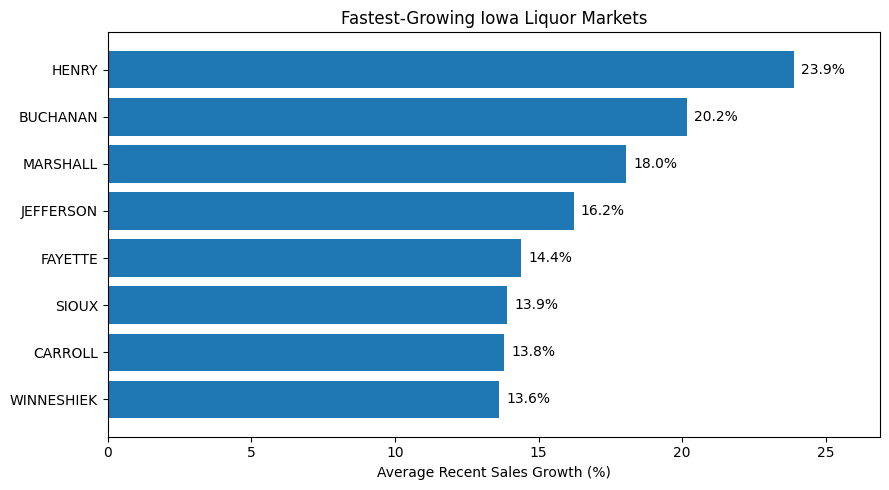

In [ ]:
# Get top 8 counties by recent growth
top_growth = (
    growth_opportunities
    .sort_values("average_recent_growth", ascending=False)
    .head(8)
    .sort_values("average_recent_growth", ascending=True)
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_growth["county"],
    top_growth["average_recent_growth"]
)

plt.xlabel("Average Recent Sales Growth (%)")
plt.ylabel("")
plt.title("Fastest-Growing Iowa Liquor Markets")

# Add percentage labels
for i, value in enumerate(top_growth["average_recent_growth"]):
    plt.text(
        value + 0.25,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, top_growth["average_recent_growth"].max() + 3)

plt.tight_layout()
plt.show()

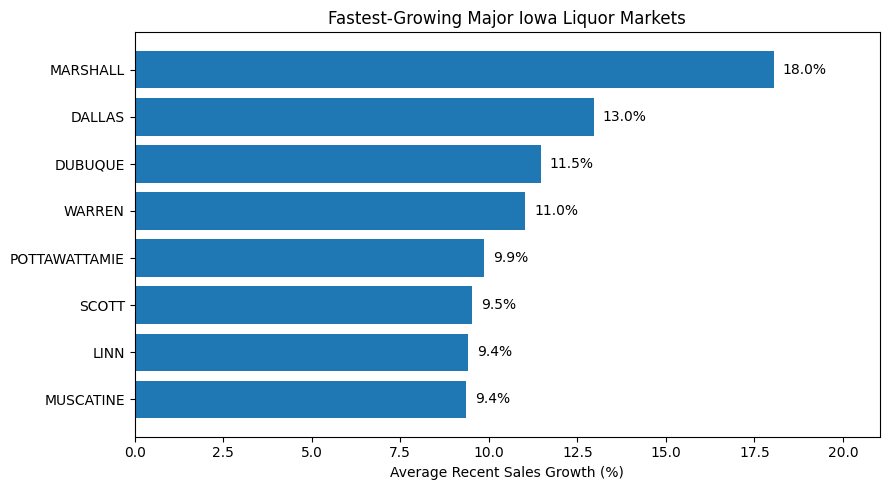

In [ ]:
# Only consider counties with at least $5M in 2025 sales
meaningful_markets = growth_opportunities[
    growth_opportunities["sales_2025"] >= 5_000_000
]

# Top 8 fastest-growing meaningful markets
top_growth = (
    meaningful_markets
    .sort_values("average_recent_growth", ascending=False)
    .head(8)
    .sort_values("average_recent_growth", ascending=True)
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_growth["county"],
    top_growth["average_recent_growth"]
)

plt.xlabel("Average Recent Sales Growth (%)")
plt.ylabel("")
plt.title("Fastest-Growing Major Iowa Liquor Markets")

for i, value in enumerate(top_growth["average_recent_growth"]):
    plt.text(
        value + 0.25,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, top_growth["average_recent_growth"].max() + 3)

plt.tight_layout()
plt.show()

In [ ]:
market_2024.sort_values(
    "sales_per_capita",
    ascending=False
)[
    [
        "county",
        "sales_dollars",
        "population",
        "sales_per_capita"
    ]
].head(15)

,county,sales_dollars,population,sales_per_capita
44,HOWARD,1.247014e+06,3105.0,401.614860
29,DICKINSON,6.907708e+06,18158.0,380.422267
22,CLINTON,1.317626e+07,46015.0,286.347040
16,CERRO GORDO,1.046897e+07,42493.0,246.369399
76,POLK,1.201590e+08,516185.0,232.782864
77,POTTAWATTAMIE,1.917922e+07,93529.0,205.061773
6,BLACK HAWK,2.657223e+07,132348.0,200.775493
13,CARROLL,3.985993e+06,20407.0,195.324773
81,SCOTT,3.356965e+07,175601.0,191.170066
56,LINN,4.404905e+07,231762.0,190.061566


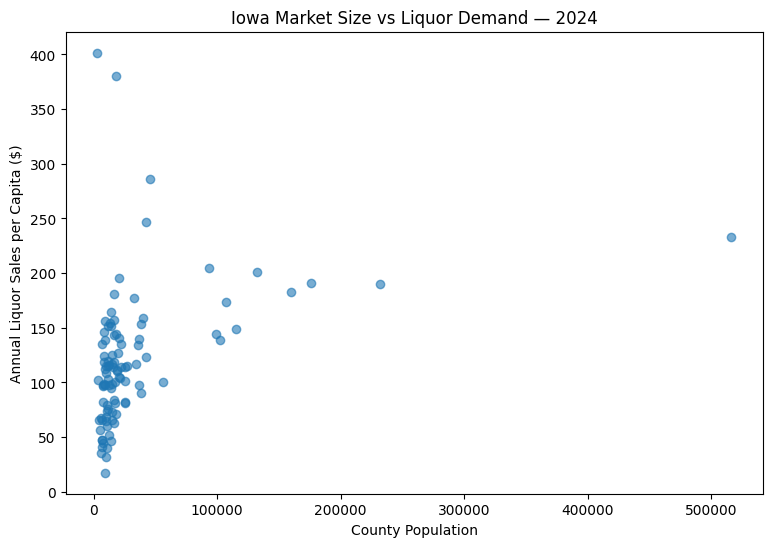

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    market_2024["population"],
    market_2024["sales_per_capita"],
    alpha=0.6
)

plt.xlabel("County Population")
plt.ylabel("Annual Liquor Sales per Capita ($)")
plt.title("Iowa Market Size vs Liquor Demand — 2024")

plt.show()

In [ ]:
print("Actual 2025 sales:")
print(test_final["sales_dollars"].sum())

print("\nOur model predicted 2025 sales:")
print(test_final["predicted_sales"].sum())

print("\nBaseline predicted 2025 sales:")
print(test_final["sales_lag_12"].sum())

Actual 2025 sales:
522799272.86

Our model predicted 2025 sales:
561421791.6677598

Baseline predicted 2025 sales:
524261844.99


In [ ]:
print("=" * 60)
print("BOOZE R' US — FINAL RESULTS")
print("=" * 60)

print()

print("FORECAST PERFORMANCE")
print(
    f"2025 test RMSE: "
    f"${final_test_rmse:,.0f}"
)

print(
    f"2025 test MAE: "
    f"${final_test_mae:,.0f}"
)

print(
    f"RMSE improvement over previous-year baseline: "
    f"{rmse_improvement:.1f}%"
)

print()

print("2026 FORECAST")
print(
    f"Projected statewide sales: "
    f"${projected_2026_sales:,.0f}"
)

print(
    f"Projected growth vs 2025: "
    f"{projected_growth:.1f}%"
)

print()

print("TOP PROJECTED MONTHS")

print(
    forecast_monthly[
        [
            "month_name",
            "predicted_sales"
        ]
    ]
    .sort_values(
        "predicted_sales",
        ascending=False
    )
    .head(3)
    .to_string(index=False)
)

print()

print("TOP PROJECTED COUNTIES")

print(
    county_forecast
    .head(5)
    .to_string()
)

print()

print("HIGH-GROWTH, MEANINGFUL-SIZE MARKETS")

print(
    growth_opportunities[
        [
            "county",
            "sales_2025",
            "average_recent_growth"
        ]
    ]
    .head(5)
    .to_string(index=False)
)

BOOZE R' US — FINAL RESULTS

FORECAST PERFORMANCE
2025 test RMSE: $549,395
2025 test MAE: $152,993
RMSE improvement over previous-year baseline: 11.3%

2026 FORECAST
Projected statewide sales: $548,865,563
Projected growth vs 2025: 5.0%

TOP PROJECTED MONTHS
month_name  predicted_sales
   October     7.774816e+07
 September     6.158769e+07
  November     6.037342e+07

TOP PROJECTED COUNTIES
county
POLK          1.249637e+08
LINN          4.679375e+07
SCOTT         3.489079e+07
JOHNSON       3.157872e+07
BLACK HAWK    2.534711e+07

HIGH-GROWTH, MEANINGFUL-SIZE MARKETS
   county  sales_2025  average_recent_growth
    HENRY  2546489.61              23.891878
 BUCHANAN  2054120.00              20.160189
 MARSHALL  7040868.45              18.043645
JEFFERSON  1913469.60              16.219145
  FAYETTE  2077403.40              14.388281


In [ ]:
historical_monthly = (
    booze[
        booze["year"] <= 2025
    ]
    .groupby(["year", "month"])["sales_dollars"]
    .sum()
    .reset_index()
)

historical_monthly[
    historical_monthly["month"].isin([9, 10, 11])
].tail(15)

,year,month,sales_dollars
116,2021,9,35837061.02
117,2021,10,38085762.36
118,2021,11,55933592.24
128,2022,9,36398734.10
129,2022,10,63842478.58
130,2022,11,75026877.26
140,2023,9,35096963.96
141,2023,10,40197690.20
142,2023,11,39289673.49
152,2024,9,34390542.61


In [ ]:
final_coefficients.sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient
12,month_12,148089.327841
10,month_10,128641.810815
11,month_11,118206.079048
5,month_5,102101.007001
3,month_3,101858.658494
2,month_2,100063.867485
8,month_8,97586.895138
4,month_4,96749.278756
6,month_6,95787.024753
9,month_9,86702.892855


In [ ]:
yearly_sales = (
    booze
    .groupby("year")["sales_dollars"]
    .sum()
    .reset_index()
)

yearly_sales

,year,sales_dollars
0,2012,2.549483e+08
1,2013,2.578993e+08
2,2014,2.704836e+08
3,2015,2.842360e+08
4,2016,2.874148e+08
5,2017,3.082467e+08
6,2018,3.337924e+08
7,2019,3.486198e+08
8,2020,4.942173e+08
9,2021,4.883318e+08


In [ ]:
monthly_2025 = (
    booze[
        booze["year"] == 2025
    ]
    .groupby("month")["sales_dollars"]
    .sum()
    .reset_index()
)

monthly_2025

,month,sales_dollars
0,1,31104178.89
1,2,31304291.10
2,3,33510150.63
3,4,35488788.34
4,5,35580187.72
5,6,35934672.00
6,7,36082054.99
7,8,52126020.51
8,9,70298451.38
9,10,80008864.30


END OF BOOZE, START OF DEAD

In [ ]:
#For dead, drop 2025 and 2026 data that has no population data, keep for booze
dead_monthly = df_main[
    df_main["county_population"].notna()
].copy()

In [ ]:
dead = (
    dead_monthly
    .groupby(
        ["county", "year"],
        as_index=False
    )
    .agg(
        sales_liters=(
            "sales_liters",
            "sum"
        ),

        sales_dollars=(
            "sales_dollars",
            "sum"
        ),

        sales_bottles=(
            "sales_bottles",
            "sum"
        ),

        county_population=(
            "county_population",
            "first"
        ),

        avg_alcohol_level_g210L=(
            "avg_alcohol_level_g210L",
            "first"
        ),

        num_tests=(
            "num_tests",
            "first"
        ),
        avg_monthly_stores=(
            "num_stores",
            "mean"
        )
    )
)

In [ ]:
dead["liters_per_capita"] = (
    dead["sales_liters"]
    / dead["county_population"]
)

dead["tests_per_1000"] = (
    dead["num_tests"]
    / dead["county_population"]
    * 1000
)

dead["stores_per_10000"] = (
    dead["avg_monthly_stores"]
    / dead["county_population"]
    * 10000
)

dead["years_since_start"] = (
    dead["year"]
    - dead["year"].min()
)

dead["log_population"] = np.log(
    dead["county_population"]
)

In [ ]:
dead.head()

,county,year,sales_liters,sales_dollars,sales_bottles,county_population,avg_alcohol_level_g210L,num_tests,avg_monthly_stores,liters_per_capita,tests_per_1000,stores_per_10000,years_since_start,log_population
0,ADAIR,2012,33297.02,413691.48,34894,7468.0,0.124,24.0,8.083333,4.458626,3.213712,10.823960,0,8.918383
1,ADAIR,2013,31159.97,378584.26,32112,7387.0,0.126,21.0,6.750000,4.218217,2.842832,9.137674,1,8.907477
2,ADAIR,2014,33383.60,413071.07,34466,7368.0,0.159,29.0,6.500000,4.530890,3.935939,8.821933,2,8.904902
3,ADAIR,2015,33957.85,424750.82,35049,7145.0,0.133,25.0,6.666667,4.752673,3.498950,9.330534,3,8.874168
4,ADAIR,2016,34773.16,444516.75,36071,7005.0,0.142,28.0,5.916667,4.964049,3.997145,8.446348,4,8.854379


In [ ]:
dead["liters_per_capita"].describe()

,liters_per_capita
count,1287.000000
mean,5.521088
std,3.047866
min,0.116174
25%,3.655524
50%,5.132168
75%,6.826776
max,31.400302


In [ ]:
dead[
    [
        "liters_per_capita",
        "stores_per_10000",
        "tests_per_1000",
        "avg_alcohol_level_g210L",
        "log_population",
        "years_since_start"
    ]
].corr()["liters_per_capita"].sort_values(
    ascending=False
)

,liters_per_capita
liters_per_capita,1.000000
stores_per_10000,0.481188
log_population,0.387608
years_since_start,0.265707
avg_alcohol_level_g210L,0.176509
tests_per_1000,0.169698


In [ ]:
dead.sort_values(
    "liters_per_capita",
    ascending=False
)[
    [
        "county",
        "year",
        "sales_liters",
        "county_population",
        "liters_per_capita"
    ]
].head(20)

,county,year,sales_liters,county_population,liters_per_capita
581,HOWARD,2021,99727.36,3176.0,31.400302
582,HOWARD,2022,94057.58,3163.0,29.736826
584,HOWARD,2024,75151.99,3105.0,24.203539
386,DICKINSON,2021,400141.76,17876.0,22.384301
387,DICKINSON,2022,401579.30,18052.0,22.245696
385,DICKINSON,2020,386052.82,17703.0,21.807198
583,HOWARD,2023,67020.40,3140.0,21.344076
389,DICKINSON,2024,382911.68,18158.0,21.087767
388,DICKINSON,2023,358413.79,18087.0,19.816099
384,DICKINSON,2019,317827.83,17258.0,18.416261


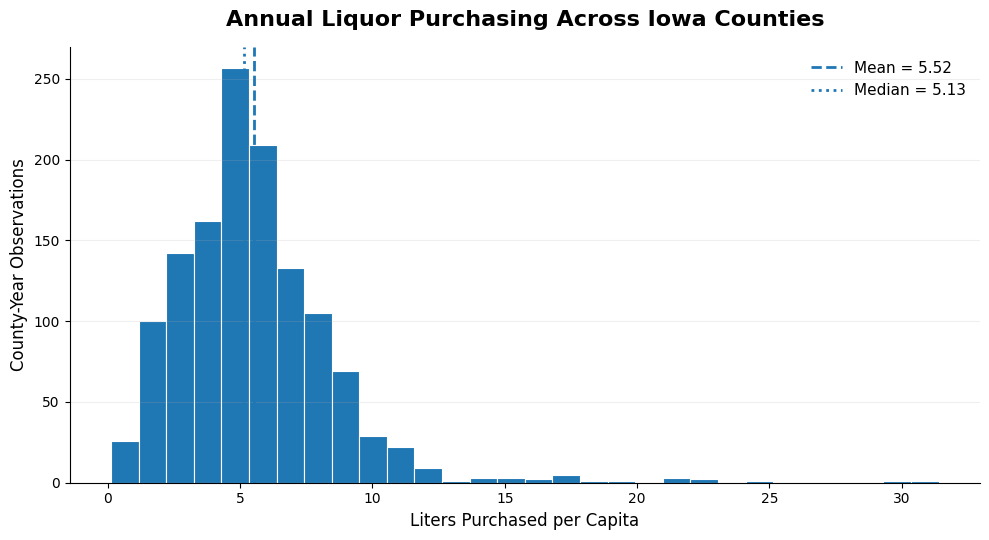

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(
    dead["liters_per_capita"],
    bins=30,
    edgecolor="white",
    linewidth=0.8
)

# Mean and median
mean_val = dead["liters_per_capita"].mean()
median_val = dead["liters_per_capita"].median()

ax.axvline(
    mean_val,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_val:.2f}"
)

ax.axvline(
    median_val,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_val:.2f}"
)

ax.set_title(
    "Annual Liquor Purchasing Across Iowa Counties",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Liters Purchased per Capita",
    fontsize=12
)

ax.set_ylabel(
    "County-Year Observations",
    fontsize=12
)

ax.legend(
    frameon=False,
    fontsize=11
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light horizontal grid
ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

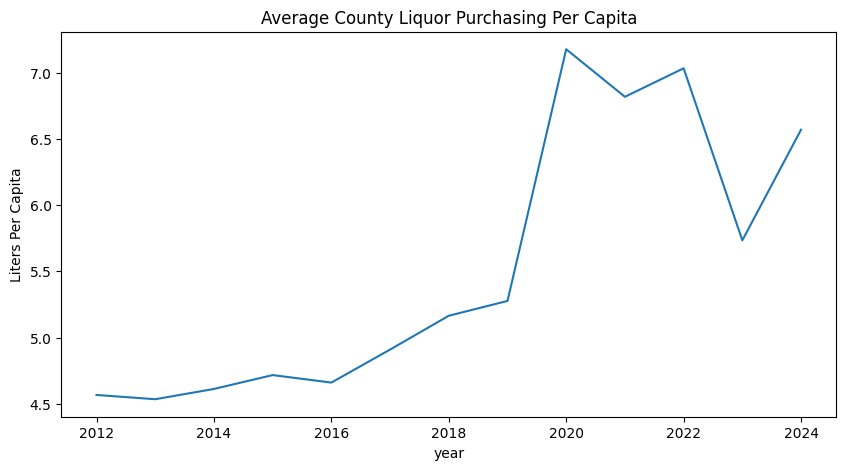

In [ ]:
yearly_dead = (
    dead.groupby("year")["liters_per_capita"]
        .mean()
)

yearly_dead.plot(
    figsize=(10, 5),
    title="Average County Liquor Purchasing Per Capita"
)

plt.ylabel("Liters Per Capita")
plt.show()

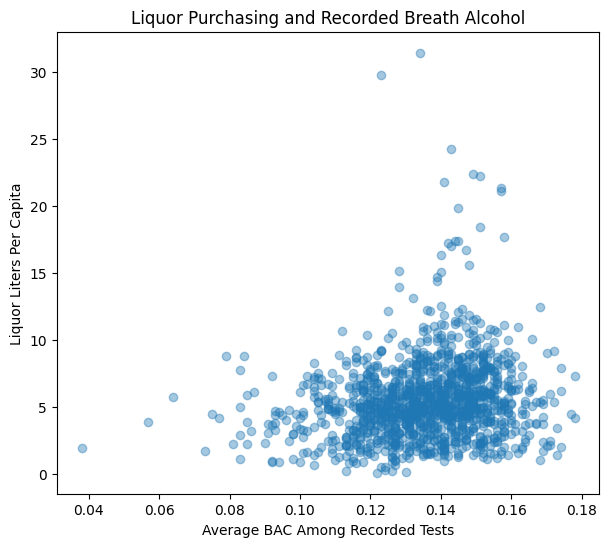

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dead["avg_alcohol_level_g210L"],
    dead["liters_per_capita"],
    alpha=0.4
)

plt.xlabel("Average BAC Among Recorded Tests")
plt.ylabel("Liquor Liters Per Capita")
plt.title("Liquor Purchasing and Recorded Breath Alcohol")

plt.show()

In [ ]:
dead[
    [
        "liters_per_capita",
        "avg_alcohol_level_g210L",
        "num_tests",
        "county_population",
        "stores_per_10000"
    ]
].corr()

,liters_per_capita,avg_alcohol_level_g210L,num_tests,county_population,stores_per_10000
liters_per_capita,1.000000,0.176509,0.318397,0.314014,0.481188
avg_alcohol_level_g210L,0.176509,1.000000,0.066375,0.120111,0.102839
num_tests,0.318397,0.066375,1.000000,0.916127,-0.161935
county_population,0.314014,0.120111,0.916127,1.000000,-0.134592
stores_per_10000,0.481188,0.102839,-0.161935,-0.134592,1.000000


In [ ]:
dead_train = dead[
    dead["year"] <= 2022
].copy()

dead_val = dead[
    dead["year"].isin([2023, 2024])
].copy()

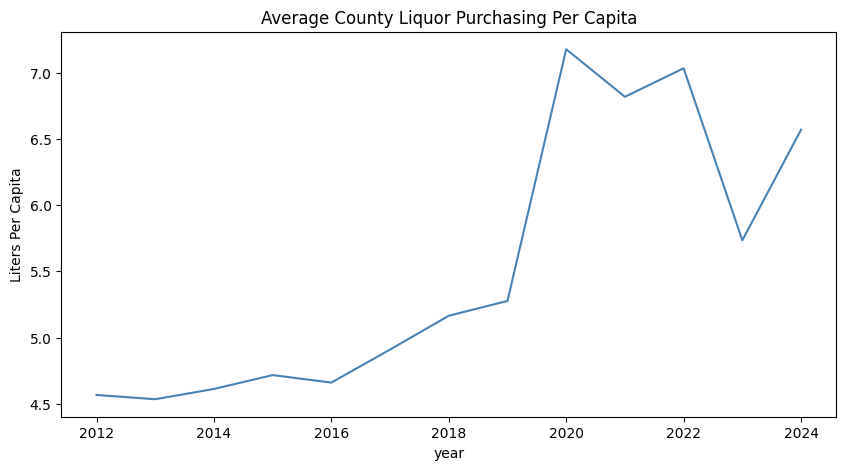

In [ ]:
yearly_dead = (
    dead.groupby("year")["liters_per_capita"]
        .mean()
)

yearly_dead.plot(
    figsize=(10, 5),
    color="steelblue",
    title="Average County Liquor Purchasing Per Capita"
)

plt.ylabel("Liters Per Capita")
plt.show()

In [ ]:
#Model 1: time only

dead_features1 = [
    "years_since_start"
]

dead_model1 = LinearRegression()

dead_model1.fit(
    dead_train[dead_features1],
    dead_train["liters_per_capita"]
)

dead_pred1 = dead_model1.predict(
    dead_val[dead_features1]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred1
    )
)

print(
    "MAE:",
    mae(
        dead_val["liters_per_capita"],
        dead_pred1
    )
)

RMSE: 3.4452661975604606
MAE: 2.5400871995816376


In [ ]:
#Model 2: Time + BAC

dead_features2 = [
    "years_since_start",
    "avg_alcohol_level_g210L"
]

dead_model2 = LinearRegression()

dead_model2.fit(
    dead_train[dead_features2],
    dead_train["liters_per_capita"]
)

dead_pred2 = dead_model2.predict(
    dead_val[dead_features2]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred2
    )
)

pd.Series(
    dead_model2.coef_,
    index=dead_features2
)

RMSE: 3.4372222580542604


,0
years_since_start,0.275987
avg_alcohol_level_g210L,31.400162


In [ ]:
#Model 3: adding test frequency

dead_features3 = [
    "years_since_start",
    "avg_alcohol_level_g210L",
    "tests_per_1000"
]

dead_model3 = LinearRegression()

dead_model3.fit(
    dead_train[dead_features3],
    dead_train["liters_per_capita"]
)

dead_pred3 = dead_model3.predict(
    dead_val[dead_features3]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred3
    )
)

print(
    pd.Series(
        dead_model3.coef_,
        index=dead_features3
    )
)

RMSE: 3.353584162970485
years_since_start           0.374619
avg_alcohol_level_g210L    38.351779
tests_per_1000              0.512339
dtype: float64


In [ ]:
dead_features4 = [
    "years_since_start",
    "avg_alcohol_level_g210L",
    "tests_per_1000",
    "log_population"
]

dead_model4 = LinearRegression()

dead_model4.fit(
    dead_train[dead_features4],
    dead_train["liters_per_capita"]
)

dead_pred4 = dead_model4.predict(
    dead_val[dead_features4]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred4
    )
)

print(
    pd.Series(
        dead_model4.coef_,
        index=dead_features4
    )
)

RMSE: 3.187733398278088
years_since_start           0.371070
avg_alcohol_level_g210L    25.654618
tests_per_1000              0.476603
log_population              1.251081
dtype: float64


In [ ]:
dead_features5 = [
    "years_since_start",
    "avg_alcohol_level_g210L",
    "tests_per_1000",
    "log_population",
    "stores_per_10000"
]

dead_model5 = LinearRegression()

dead_model5.fit(
    dead_train[dead_features5],
    dead_train["liters_per_capita"]
)

dead_pred5 = dead_model5.predict(
    dead_val[dead_features5]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred5
    )
)

print(
    pd.Series(
        dead_model5.coef_,
        index=dead_features5
    )
)

RMSE: 2.704844267077184
years_since_start           0.132131
avg_alcohol_level_g210L    13.313780
tests_per_1000              0.349018
log_population              1.658919
stores_per_10000            0.806690
dtype: float64


In [ ]:
results_dead = pd.DataFrame({
    "Model": [
        "Time trend",
        "Time + BAC",
        "Time + BAC + Tests",
        "Time + BAC + Tests + Population",
        "Time + BAC + Tests + Population + Stores"
    ],

    "RMSE": [
        rmse(
            dead_val["liters_per_capita"],
            dead_pred1
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred2
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred3
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred4
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred5
        )
    ]
})

results_dead.sort_values("RMSE")

,Model,RMSE
4,Time + BAC + Tests + Population + Stores,2.704844
3,Time + BAC + Tests + Population,3.187733
2,Time + BAC + Tests,3.353584
1,Time + BAC,3.437222
0,Time trend,3.445266


In [ ]:
coefficients = pd.DataFrame({
    "Factor": dead_features5,
    "Coefficient": dead_model5.coef_
})

coefficients

,Factor,Coefficient
0,years_since_start,0.132131
1,avg_alcohol_level_g210L,13.313780
2,tests_per_1000,0.349018
3,log_population,1.658919
4,stores_per_10000,0.806690


In [ ]:
X_train = dead_train[dead_features5]
y_train = dead_train["liters_per_capita"]

X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_std = (
    X_train - X_mean
) / X_std

y_train_std = (
    y_train - y_mean
) / y_std

dead_model5_std = LinearRegression()

dead_model5_std.fit(
    X_train_std,
    y_train_std
)

standardized_coefs = pd.DataFrame({
    "Factor": dead_features5,
    "Standardized Coefficient":
        dead_model5_std.coef_
})

standardized_coefs[
    "Absolute Coefficient"
] = standardized_coefs[
    "Standardized Coefficient"
].abs()

standardized_coefs.sort_values(
    "Absolute Coefficient",
    ascending=False
)

,Factor,Standardized Coefficient,Absolute Coefficient
4,stores_per_10000,0.517189,0.517189
3,log_population,0.491936,0.491936
2,tests_per_1000,0.214954,0.214954
0,years_since_start,0.139917,0.139917
1,avg_alcohol_level_g210L,0.076824,0.076824


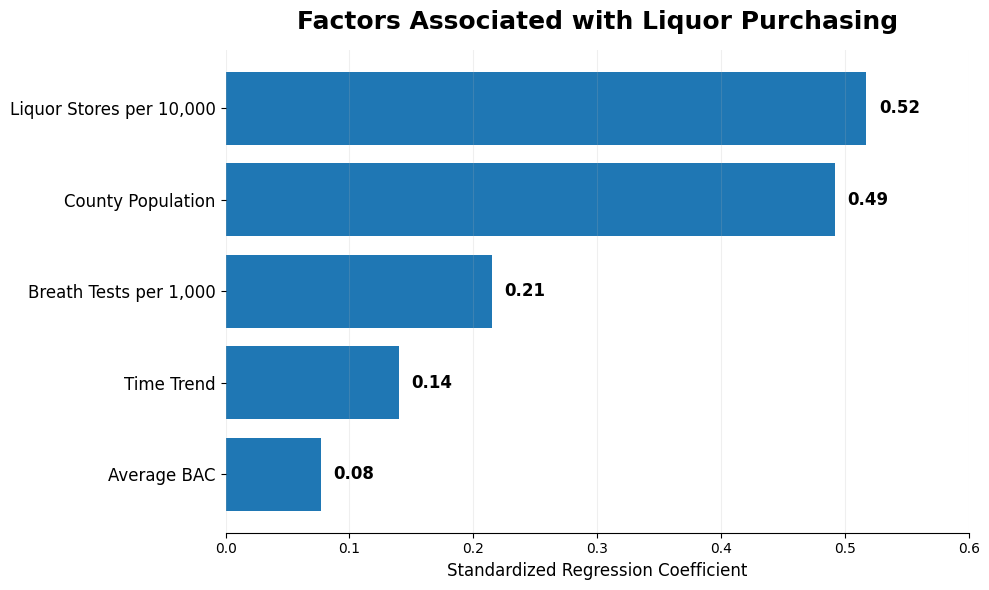

In [ ]:
# Final standardized coefficients
coef_plot = pd.DataFrame({
    "Factor": [
        "Liquor Stores per 10,000",
        "County Population",
        "Breath Tests per 1,000",
        "Time Trend",
        "Average BAC"
    ],
    "Coefficient": [
        0.517189,
        0.491936,
        0.214954,
        0.139917,
        0.076824
    ]
})

# Sort so largest appears at top
coef_plot = coef_plot.sort_values(
    "Coefficient",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    coef_plot["Factor"],
    coef_plot["Coefficient"]
)

# Put coefficient values at end of bars
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

ax.set_title(
    "Factors Associated with Liquor Purchasing",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Standardized Regression Coefficient",
    fontsize=12
)

ax.set_ylabel("")

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Subtle grid
ax.grid(
    axis="x",
    alpha=0.2
)

ax.set_xlim(0, 0.6)

ax.tick_params(
    axis="y",
    labelsize=12
)

plt.tight_layout()
plt.show()

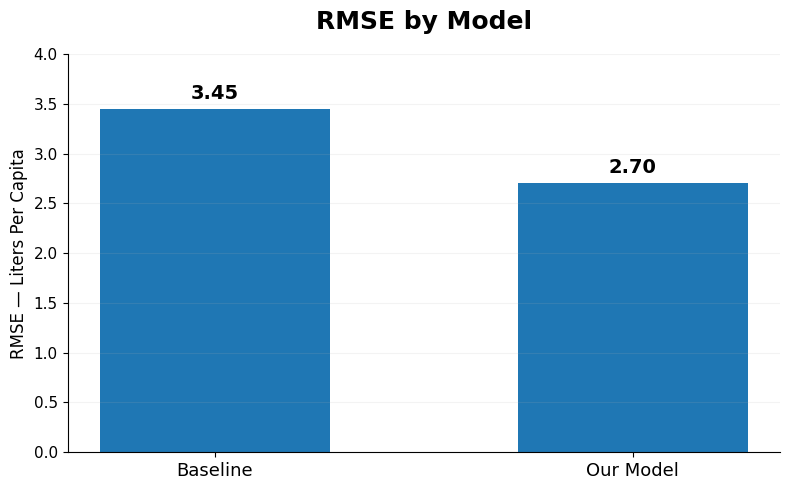

In [ ]:
baseline_rmse = 3.445266
model_rmse = 2.704844

improvement = (
    (baseline_rmse - model_rmse)
    / baseline_rmse
    * 100
)

labels = ["Baseline", "Our Model"]
values = [baseline_rmse, model_rmse]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    values,
    width=0.55
)

# Value labels above bars
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.06,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

ax.set_title(
    "RMSE by Model",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_ylabel(
    "RMSE — Liters Per Capita",
    fontsize=12
)

ax.set_ylim(0, 4)

# Match the clean Booze slide style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelsize=13
)

ax.tick_params(
    axis="y",
    labelsize=11
)

ax.grid(
    axis="y",
    alpha=0.15
)

plt.tight_layout()
plt.show()

In [ ]:
county_priority = (
    dead.groupby("county")
    .agg(
        purchasing=(
            "liters_per_capita",
            "mean"
        ),
        store_availability=(
            "stores_per_10000",
            "mean"
        ),
        testing_rate=(
            "tests_per_1000",
            "mean"
        ),
        years_observed=(
            "year",
            "nunique"
        )
    )
    .reset_index()
)

In [ ]:
indicators = [
    "purchasing",
    "store_availability",
    "testing_rate"
]

for col in indicators:
    county_priority[col + "_z"] = (
        county_priority[col]
        - county_priority[col].mean()
    ) / county_priority[col].std()

In [ ]:
county_priority["priority_index"] = (
    county_priority["purchasing_z"]
    + county_priority["store_availability_z"]
    + county_priority["testing_rate_z"]
) / 3
county_priority.sort_values(
    "priority_index",
    ascending=False
).head(10)

,county,purchasing,store_availability,testing_rate,years_observed,purchasing_z,store_availability_z,testing_rate_z,priority_index
29,DICKINSON,18.882199,7.920858,8.661997,13,4.964664,1.807414,3.315337,3.362472
44,HOWARD,12.849851,10.893683,6.218501,13,2.723190,3.767255,1.444477,2.644974
16,CERRO GORDO,11.940725,4.940652,7.144253,13,2.385381,-0.157293,2.153278,1.460456
19,CLARKE,5.882953,7.266011,6.635709,13,0.134460,1.375705,1.763912,1.091359
41,HARDIN,9.100624,8.051406,4.334061,13,1.330069,1.893478,0.001658,1.075068
98,WRIGHT,4.663528,8.516940,6.046304,13,-0.318649,2.200382,1.312635,1.064790
10,BUENA VISTA,6.935412,6.051226,6.826679,13,0.525528,0.574856,1.910128,1.003504
51,JOHNSON,8.420125,3.843335,7.831509,13,1.077212,-0.880701,2.679474,0.958662
70,O'BRIEN,7.983091,7.812351,4.304089,13,0.914821,1.735881,-0.021289,0.876471
73,PALO ALTO,6.969138,8.746780,3.948485,13,0.538060,2.351904,-0.293557,0.865469


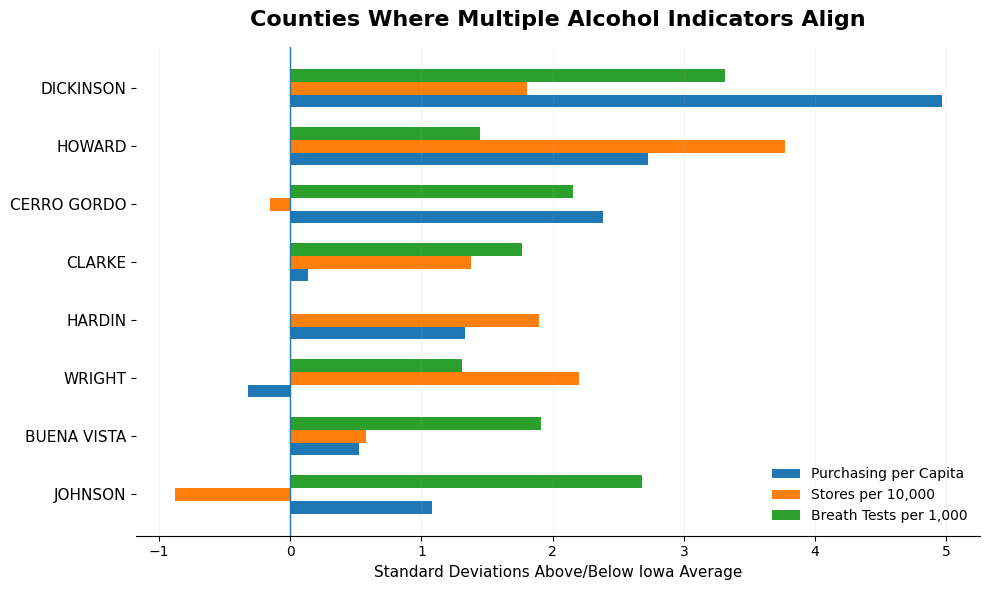

In [ ]:
top_counties = (
    county_priority
    .sort_values(
        "priority_index",
        ascending=False
    )
    .head(8)
    .copy()
)

# Reverse so highest appears at top
top_counties = top_counties.iloc[::-1]

y = np.arange(len(top_counties))
height = 0.22

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    y - height,
    top_counties["purchasing_z"],
    height,
    label="Purchasing per Capita"
)

ax.barh(
    y,
    top_counties["store_availability_z"],
    height,
    label="Stores per 10,000"
)

ax.barh(
    y + height,
    top_counties["testing_rate_z"],
    height,
    label="Breath Tests per 1,000"
)

ax.set_yticks(y)

ax.set_yticklabels(
    top_counties["county"],
    fontsize=11
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Standard Deviations Above/Below Iowa Average",
    fontsize=11
)

ax.set_title(
    "Counties Where Multiple Alcohol Indicators Align",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.15
)

plt.tight_layout()
plt.show()

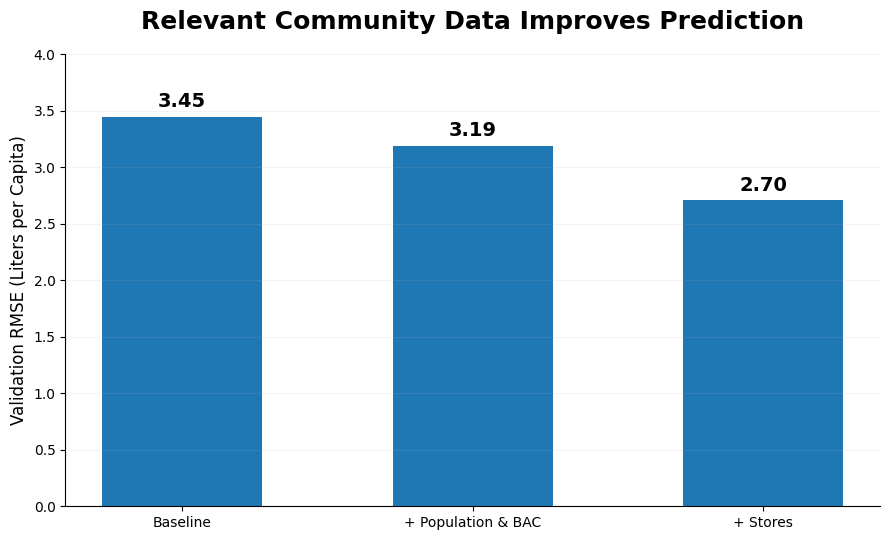

In [ ]:
labels = [
    "Baseline",
    "+ Population & BAC",
    "+ Stores"
]

rmse_values = [
    3.445266,
    3.187733,
    2.704844
]

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    labels,
    rmse_values,
    width=0.55
)

# Add RMSE above each bar
for bar, value in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

ax.set_title(
    "Relevant Community Data Improves Prediction",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_ylabel(
    "Validation RMSE (Liters per Capita)",
    fontsize=12
)

ax.set_ylim(0, 4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.15
)

plt.tight_layout()
plt.show()